In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import glob
from torch.utils.data import TensorDataset, DataLoader
import math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
#选择在GPU或CPU上面运行
device=torch.device('cuda:0' if torch.cuda.is_available else 'cpu')
print(device)

cuda:0


In [3]:
data = []
labels = []

# 拿到数据路径，方便后续读取
dir_path = 'D:\\Desktop\\Python\\Signal_reconstruction\\Numerical_simulation_Data\\test'
# 获取目录及其子目录下所有CSV文件的路径
dataPaths = sorted(glob.glob(os.path.join(dir_path, '**', '*.csv'), recursive=True))
random.seed(42)
random.shuffle(dataPaths)

# 遍历读取数据
for dataPath in dataPaths:
    # 读取数据
    data_1 = pd.read_csv(dataPath)
    data.append(data_1.iloc[1:10001, 1])

# 将数据和标签转换为numpy数组
test_data = np.array(data, dtype="float")
test_labels = np.array(data, dtype="float")

In [4]:
test_datas=test_data.reshape(-1,test_data.shape[1],1)
print(test_datas.shape)

(220, 10000, 1)


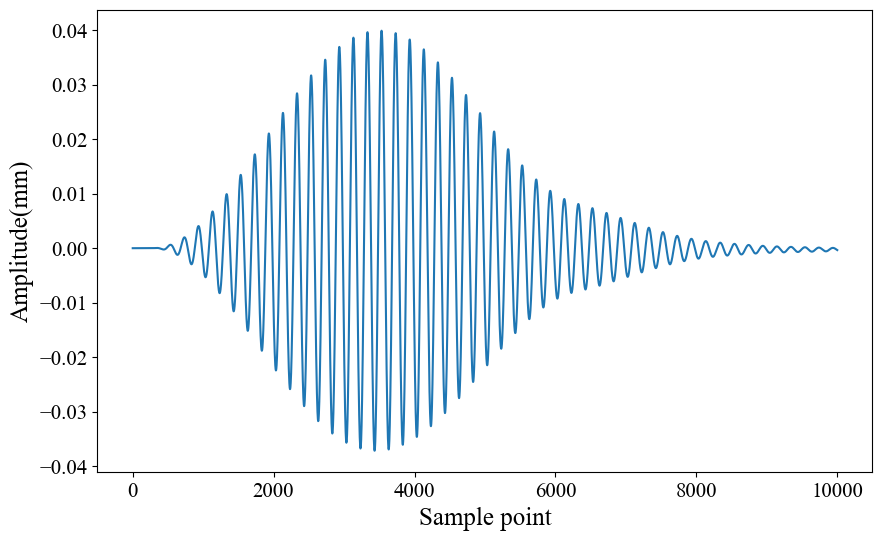

In [5]:
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(test_datas[0,:],linewidth=1.5)
plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(mm)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.savefig('D:\\Desktop\\Python\\Signal_reconstruction\\Model\\MSE\\test_data.jpg', dpi=600, bbox_inches='tight')

In [6]:
def add_noise_with_snr(signal, snr_db):
    """
    根据信噪比（dB）为信号添加高斯噪声
    :param signal: 原始信号
    :param snr_db: 信噪比（dB）
    :return: 带噪声的信号
    """
    # 计算信号功率
    signal_power = np.mean(signal ** 2)
    
    # 将信噪比从分贝转换为线性比例
    snr_linear = 10 ** (snr_db / 10)
    
    # 计算噪声功率
    noise_power = signal_power / snr_linear
    
    # 生成高斯噪声
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    
    # 添加噪声
    noisy_signal = signal + noise
    return noisy_signal

In [7]:
def calculate_snr(x_prime, x):
    """
    计算信号的信噪比（SNR）。

    参数:
        x (numpy.ndarray): 干净信号。
        x_prime (numpy.ndarray): 噪声信号。

    返回:
        float: 信噪比，单位为 dB。
    """
    # 计算信号功率
    signal_power = torch.mean(x ** 2)
    
    noise = x_prime-x
    # 计算噪声功率
    noise_power = torch.mean(noise ** 2)
    
    # 计算信噪比
    if noise_power == 0:
        raise ValueError("噪声功率不能为零，这可能导致除以零的错误。")
    
    snr = 10 * torch.log10(signal_power / noise_power)
    
    snr_1 = snr.to(device)
    return snr_1.item()  # 将结果转换为 Python 标量

In [8]:
def calculate_pcc(x, y):
    """
    计算两个信号的皮尔逊相关系数（PCC）。

    参数:
        x (torch.Tensor): 第一个信号，假定在 CUDA 上。
        y (torch.Tensor): 第二个信号，假定在 CUDA 上。

    返回:
        float: 皮尔逊相关系数。
    """
    
    # 计算均值
    mean_x = torch.mean(x)
    mean_y = torch.mean(y)
    
    # 计算协方差
    covariance = torch.mean((x - mean_x) * (y - mean_y))
    
    # 计算标准差
    std_x = torch.std(x)
    std_y = torch.std(y)
    
    # 计算皮尔逊相关系数
    if std_x == 0 or std_y == 0:
        raise ValueError("标准差不能为零，这可能导致除以零的错误。")
    
    pcc = covariance / (std_x * std_y)

    pcc_1 = pcc.to(device)

    return pcc_1.item()  # 将结果转换为 Python 标量


In [9]:
# 添加噪声，信噪比为20dB
snr_db = 20  # 信噪比（dB）
test_noisy_signal = add_noise_with_snr(test_datas, snr_db)
print(f'test_noisy_signal.shape:{test_noisy_signal.shape}')

test_noisy_signal.shape:(220, 10000, 1)


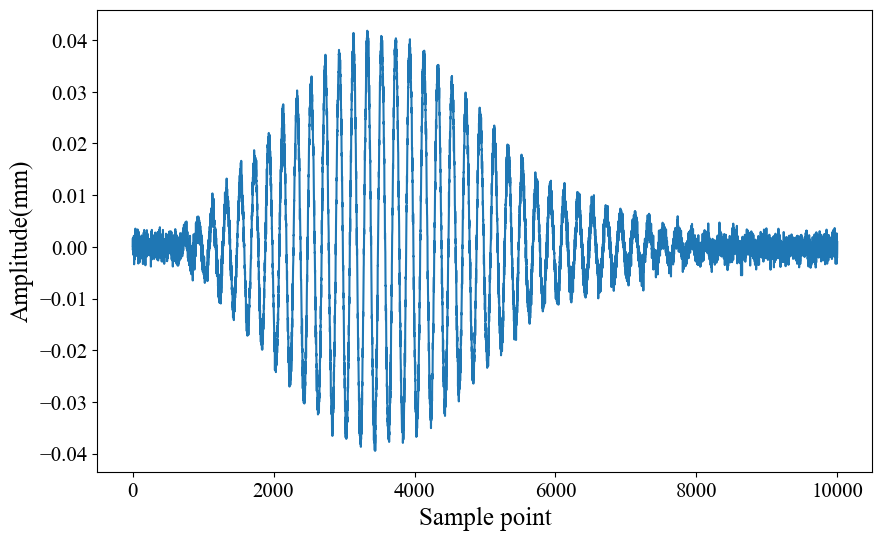

In [10]:
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(test_noisy_signal[0,:],linewidth=1.5)
plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(mm)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.savefig('D:\\Desktop\\Python\\Signal_reconstruction\\Model\\MSE\\test_data_noise.jpg', dpi=600, bbox_inches='tight')

In [11]:
BATCH_SIZE=1

In [12]:
# 准备数据
#torch.from_numpy将 NumPy 数组转换为 PyTorch 张量
#TensorDataset用于将张量数据和标签组合成一个数据集
#DataLoader用于从数据集中加载批次数据，并进行训练或测试

test_dataset = TensorDataset(torch.from_numpy(test_noisy_signal),torch.from_numpy(test_labels))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, N, n):
        super(Conv1DAutoencoder, self).__init__()
        self.N = N
        self.n = n
        self.compression_ratio = n

        # 根据压缩比计算卷积层数量
        self.num_conv_layers = int(math.log2(n))  # 假设 n 是 2 的幂次方

        # 编码器部分
        self.encoder_layers = nn.ModuleList()
        in_channels = 1
        for i in range(self.num_conv_layers):
            out_channels = 1  # 每一层的输出通道数为1
            stride = 2  # 每一层的步长为2
            self.encoder_layers.append(
                nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
            )
            self.encoder_layers.append(nn.Tanh())
            in_channels = out_channels

        # 解码器部分
        self.decoder_layers = nn.ModuleList()
        in_channels = 1
        for i in range(self.num_conv_layers - 1):
            out_channels = 1  # 每一层的输出通道数为1
            stride = 2  # 每一层的步长为2
            self.decoder_layers.append(
                nn.ConvTranspose1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, output_padding=1)
            )
            self.decoder_layers.append(nn.Tanh())
            in_channels = out_channels

        # 最后一层反卷积，确保输出维度为 [batch_size, 1, N]
        self.decoder_layers.append(
            nn.ConvTranspose1d(in_channels, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        # 编码器
        for i, layer in enumerate(self.encoder_layers):
            x = layer(x)

        # 解码器
        for i, layer in enumerate(self.decoder_layers):
            x = layer(x)
        x=x[:,:,:10000]
        return x

In [14]:
N=test_data.shape[1]
n=64
model=torch.load(f'D:\\Desktop\\Python\\Signal_reconstruction\\Model\\MSE\\model_signal_reconstruction_MSE_{n}.pth')  # 加载训练好的模型参数
model.to(device)
loss = nn.MSELoss()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16880\2641998695.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model=torch.load(f'D:\\Desktop\\Python\\Signal_recon

In [15]:
# 将模型设置为评估模式
model.eval()  
# 进行预测

signal_reconstruction = []
signal_origin=[]

for i, (x, y) in enumerate(test_loader):
    
    x1=x.type(torch.FloatTensor)
    y1=y.type(torch.FloatTensor)

    x2=x1.reshape(BATCH_SIZE,1,-1)
    y2=y1.reshape(BATCH_SIZE,1,-1)

    x3,y3=x2.to(device),y2.to(device)

    with torch.no_grad():  # 关闭梯度计算
        y_hat = model(x3)
        signal_origin.append(y3)
        signal_reconstruction.append(y_hat)

In [16]:
a=10
signal_origin_1 = signal_origin[a]
reconstructed_signal_1 = signal_reconstruction[a]

# 将重构信号移动到CPU并转换为NumPy数组
signal_origin_3 = signal_origin_1.cpu().numpy().squeeze()
reconstructed_signal = reconstructed_signal_1.cpu().numpy().squeeze()

In [17]:
y_loss = 1e4*loss(reconstructed_signal_1,signal_origin_1)
SNR=calculate_snr(reconstructed_signal_1,signal_origin_1)
PCC=calculate_pcc(reconstructed_signal_1,signal_origin_1)
print(f'Reconstruction_error:{y_loss:.4f}')
print(f'Reconstruction_SNR:{SNR:.4f}')
print(f'Reconstruction_PCC:{PCC:.4f}')

Reconstruction_error:0.0017
Reconstruction_SNR:30.0037
Reconstruction_PCC:0.9994


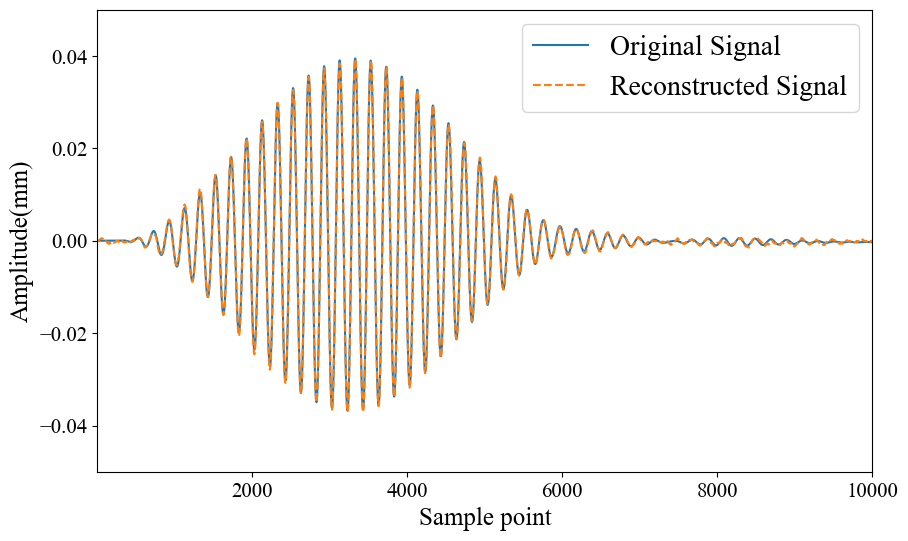

In [18]:
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(signal_origin_3,linewidth=1.5, label='Original Signal')
plt.plot(reconstructed_signal,linewidth=1.5, linestyle='--',label='Reconstructed Signal')

plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(mm)',fontdict={'weight': 'normal', 'size': 18})

plt.xlim([10,1e4])
plt.ylim([-0.05,0.05])
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.legend(loc='upper right', fontsize=20)
plt.savefig(f'D:\\Desktop\\Python\\Signal_reconstruction\\Model\\MSE\\test_data_reconstruction_{n}.jpg', dpi=600, bbox_inches='tight')

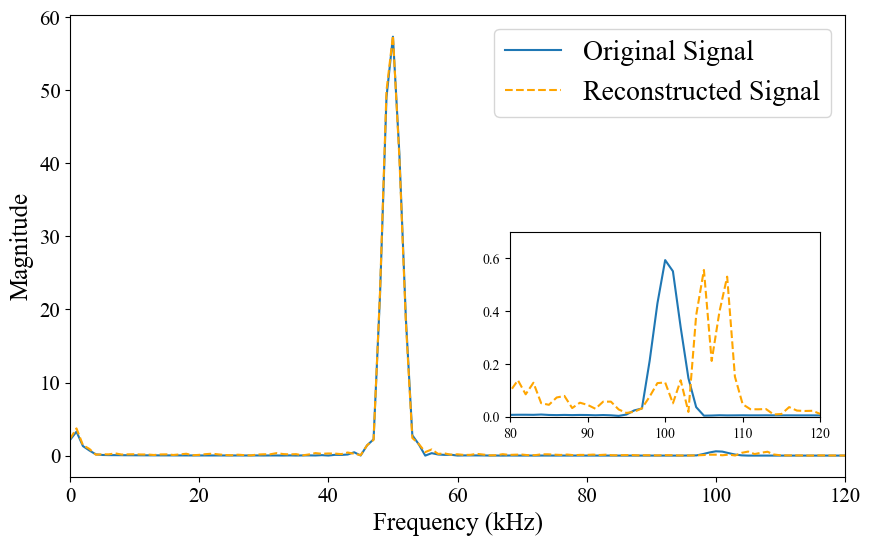

In [19]:
# 计算FFT
def calculate_fft(signal, sampling_rate):
    N = len(signal)  # 信号长度
    fft_values = np.fft.fft(signal)  # 计算FFT
    fft_magnitude = np.abs(fft_values)  # 取模
    fft_magnitude = fft_magnitude[:N // 2]  # 只取一半（正频率部分）
    freq = np.fft.fftfreq(N, d=1 / sampling_rate)[:N // 2]  # 频率轴
    return freq, fft_magnitude

# 采样率
sampling_rate = 1e7

# 假设 Original_signal 和 reconstructed_signal 已经定义
freq_origin, fft_magnitude_origin = calculate_fft(signal_origin_3, sampling_rate)
freq_reconstructed, fft_magnitude_reconstructed = calculate_fft(reconstructed_signal, sampling_rate)

# 绘制FFT频谱图
fig, ax = plt.subplots(figsize=(10, 6))
# 信号的FFT
ax.plot(freq_origin/1e3, fft_magnitude_origin, label='Original Signal')
ax.plot(freq_reconstructed/1e3, fft_magnitude_reconstructed, linestyle='--', label='Reconstructed Signal', color='orange')
ax.set_xlabel('Frequency (kHz)', fontdict={'weight': 'normal', 'size': 18})
ax.set_ylabel('Magnitude', fontdict={'weight': 'normal', 'size': 18})
ax.legend()
ax.set_xlim([0, 120])
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(loc='upper right', fontsize=20)

# 创建局部放大图，手动指定位置
# bbox_to_anchor 是一个四元组 (x, y, width, height)，表示局部放大图的位置和大小
# bbox_transform=ax.transAxes 表示使用主图的坐标系
axins = inset_axes(ax, width="40%", height="40%", loc='lower left',
                   bbox_to_anchor=(0.55, 0.1, 1, 1), bbox_transform=ax.transAxes, borderpad=1)
axins.plot(freq_origin/1e3, fft_magnitude_origin, label='Original Signal')
axins.plot(freq_reconstructed/1e3, fft_magnitude_reconstructed, linestyle='--', label='Reconstructed Signal', color='orange')
axins.set_xlim([80, 120])
axins.set_ylim([0, 0.7])
axins.tick_params(axis='both', which='major', labelsize=10)

plt.savefig(f'D:\\Desktop\\Python\\Signal_reconstruction\\Model\\MSE\\test_reconstruction_FFT_{n}.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [20]:
fft_magnitude_reconstructed,fft_magnitude_origin=torch.from_numpy(fft_magnitude_reconstructed),torch.from_numpy(fft_magnitude_origin),

y_loss = 1e4*loss(fft_magnitude_reconstructed,fft_magnitude_origin)
SNR=calculate_snr(fft_magnitude_reconstructed,fft_magnitude_origin)
PCC=calculate_pcc(fft_magnitude_reconstructed,fft_magnitude_origin)
print(f'Reconstruction_error:{y_loss:.4f}')
print(f'Reconstruction_SNR:{SNR:.4f}')
print(f'Reconstruction_PCC:{PCC:.4f}')

Reconstruction_error:12.5331
Reconstruction_SNR:31.2040
Reconstruction_PCC:0.9994
